In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import os

print("Datasets available in /kaggle/input:")
print(os.listdir("/kaggle/input"))

Datasets available in /kaggle/input:
['datasets']


In [3]:
import os

dataset_path = "/kaggle/input/datasets"

print("Contents of dataset folder:")
print(os.listdir(dataset_path))

Contents of dataset folder:
['hungle3401']


In [4]:
import os

path = "/kaggle/input/datasets/hungle3401"

print("Contents:")
print(os.listdir(path))

Contents:
['faceforensics']


In [5]:
import os

path = "/kaggle/input/datasets/hungle3401/faceforensics"

print("Contents of faceforensics:")
print(os.listdir(path))

Contents of faceforensics:
['FF++']


In [6]:
import os

path = "/kaggle/input/datasets/hungle3401/faceforensics/FF++"

print("Contents of FF++:")
print(os.listdir(path))

Contents of FF++:
['fake', 'real']


In [7]:
import os

base_path = "/kaggle/input/datasets/hungle3401/faceforensics/FF++"

real_path = os.path.join(base_path, "real")
fake_path = os.path.join(base_path, "fake")

real_videos = [
    f for f in os.listdir(real_path)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
]

fake_videos = [
    f for f in os.listdir(fake_path)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
]

print("Number of REAL videos:", len(real_videos))
print("Number of FAKE videos:", len(fake_videos))

print("\nFirst 5 REAL videos:")
print(real_videos[:5])

print("\nFirst 5 FAKE videos:")
print(fake_videos[:5])

Number of REAL videos: 200
Number of FAKE videos: 200

First 5 REAL videos:
['08__talking_against_wall.mp4', '14__walking_down_indoor_hall_disgust.mp4', '08__walking_down_street_outside_angry.mp4', '05__outside_talking_still_laughing.mp4', '14__exit_phone_room.mp4']

First 5 FAKE videos:
['02_13__exit_phone_room__CP5HFV3K.mp4', '03_14__talking_against_wall__ZC2KYASW.mp4', '03_15__outside_talking_pan_laughing__Y11NT1YX.mp4', '07_26__walking_down_street_outside_angry__FGNGC2GT.mp4', '07_03__hugging_happy__7NGMD8FT.mp4']


In [8]:
# Deepfake Face Classification with ResNeXt101 and PyTorch

# Block 1: Install & import necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [9]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# Block 2: Face-aware frame extraction function
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def extract_faces_from_video(
    video_path,
    frame_count=10,
    output_size=(128,128),
    face_cascade=face_cascade
):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total // frame_count, 1)

    faces = []
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        dets = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5
        )
        if len(dets) > 0:
            x, y, w, h = max(dets, key=lambda r: r[2]*r[3])
            face = frame[y:y+h, x:x+w]
            face = cv2.resize(face, output_size)
            faces.append(face)
    cap.release()
    return faces  # list of 10 cropped face images or fewer


In [4]:
# Block 3: Prepare face dataset (extract, label, split)
REAL_VID_DIR = "/kaggle/input/datasets/hungle3401/faceforensics/FF++/real"
FAKE_VID_DIR = "/kaggle/input/datasets/hungle3401/faceforensics/FF++/fake"
FRAME_COUNT = 10
TMP_DIR = "/kaggle/working/faces_tmp"
os.makedirs(TMP_DIR, exist_ok=True)

filepaths, labels = [], []

# extract faces and save images
for label, vid_dir in [(0, REAL_VID_DIR), (1, FAKE_VID_DIR)]:
    for vf in tqdm(os.listdir(vid_dir)[:200], desc=f"Processing {'Real' if label==0 else 'Fake'}"):
        vid_path = os.path.join(vid_dir, vf)
        faces = extract_faces_from_video(vid_path, FRAME_COUNT)
        if len(faces) == FRAME_COUNT:
            for idx, face in enumerate(faces):
                out_path = os.path.join(TMP_DIR, f"{label}_{vf}_{idx}.jpg")
                cv2.imwrite(out_path, face)
                filepaths.append(out_path)
                labels.append(label)

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    filepaths, labels, test_size=0.2, stratify=labels, random_state=42
)


Processing Real:   0%|          | 0/200 [00:00<?, ?it/s]


NameError: name 'extract_faces_from_video' is not defined

In [11]:
import os

path = "/kaggle/working/faces_tmp"

print("faces_tmp exists:", os.path.exists(path))

if os.path.exists(path):
    files = os.listdir(path)
    print("Number of extracted files:", len(files))
    print("First 10 files:", files[:10])

faces_tmp exists: True
Number of extracted files: 3040
First 10 files: ['1_07_21__exit_phone_room__K7KXUHMU.mp4_6.jpg', '0_12__podium_speech_happy.mp4_2.jpg', '0_12__walking_down_street_outside_angry.mp4_7.jpg', '0_10__walking_outside_cafe_disgusted.mp4_0.jpg', '0_04__outside_talking_still_laughing.mp4_7.jpg', '0_07__kitchen_pan.mp4_2.jpg', '0_05__talking_against_wall.mp4_9.jpg', '1_03_14__walking_down_street_outside_angry__H0VQHGS3.mp4_8.jpg', '1_06_26__kitchen_pan__L5BVR5L9.mp4_4.jpg', '1_07_21__exit_phone_room__K7KXUHMU.mp4_1.jpg']


In [12]:
# Recreate filepaths and labels from the already extracted face images

import os
from sklearn.model_selection import train_test_split

TMP_DIR = "/kaggle/working/faces_tmp"

filepaths = []
labels = []

for filename in os.listdir(TMP_DIR):
    if filename.lower().endswith(".jpg"):
        path = os.path.join(TMP_DIR, filename)

        # 0 = Real, 1 = Fake
        label = int(filename[0])

        filepaths.append(path)
        labels.append(label)

print("Total face images:", len(filepaths))
print("Real images:", labels.count(0))
print("Fake images:", labels.count(1))

# Same 80/20 split used in the original project
X_train, X_val, y_train, y_val = train_test_split(
    filepaths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

Total face images: 3040
Real images: 1410
Fake images: 1630
Training images: 2432
Validation images: 608


In [13]:
# Block 4: Dataset and DataLoader
class FaceFrameDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_ds = FaceFrameDataset(X_train, y_train, transform)
val_ds   = FaceFrameDataset(X_val,   y_val,   transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

In [14]:
# Block 5: Load ResNeXt101 classifier
model = models.resnext101_32x8d(pretrained=True)
for param in model.parameters(): param.requires_grad = False
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth" to /root/.cache/torch/hub/checkpoints/resnext101_32x8d-8ba56ff5.pth


100%|██████████| 340M/340M [00:01<00:00, 200MB/s]  


In [15]:

# Block 6: Training loop
def train(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1)==lbls).sum().item()
        print(f"Train Loss: {total_loss/len(train_loader.dataset):.4f}",
              f"Acc: {total_correct/len(train_loader.dataset):.4f}")

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                val_loss += criterion(out, lbls).item() * imgs.size(0)
                val_correct += (out.argmax(1)==lbls).sum().item()
        print(f"Val Loss: {val_loss/len(val_loader.dataset):.4f}",
              f"Val Acc: {val_correct/len(val_loader.dataset):.4f}\n")


In [16]:
# Block 7: Run training
train(model, train_loader, val_loader, epochs=8)

Epoch 1: 100%|██████████| 76/76 [00:18<00:00,  4.12it/s]


Train Loss: 0.6439 Acc: 0.6123
Val Loss: 0.5423 Val Acc: 0.7401



Epoch 2: 100%|██████████| 76/76 [00:17<00:00,  4.25it/s]


Train Loss: 0.5252 Acc: 0.7348
Val Loss: 0.4815 Val Acc: 0.7697



Epoch 3: 100%|██████████| 76/76 [00:18<00:00,  4.10it/s]


...

Train Loss: 0.4140 Acc: 0.7932
Val Loss: 0.4271 Val Acc: 0.7829



Epoch 7: 100%|██████████| 76/76 [00:18<00:00,  4.07it/s]


Train Loss: 0.3988 Acc: 0.8026
Val Loss: 0.3763 Val Acc: 0.8339



Epoch 8: 100%|██████████| 76/76 [00:18<00:00,  4.08it/s]


Train Loss: 0.3641 Acc: 0.8326
Val Loss: 0.4341 Val Acc: 0.7977



In [17]:
# Block 8: Save model
torch.save(model.state_dict(), "resnext101_deepfake_faces.pth")

In [18]:
# Function to predict whether a video is REAL or FAKE

def predict_video(video_path, model, transform, device, frame_count=10, return_details=False):

    # Extract face crops from the video
    faces = extract_faces_from_video(video_path, frame_count)

    if len(faces) == 0:
        raise ValueError("No faces could be detected in the video.")

    model.eval()

    real_probs = []
    fake_probs = []

    with torch.no_grad():

        for face in faces:

            # Convert face to the same format used during training
            face_tensor = transform(face).unsqueeze(0).to(device)

            # Get model output
            output = model(face_tensor)

            # Convert output to probabilities
            probs = torch.softmax(output, dim=1)

            real_probs.append(probs[0, 0].item())
            fake_probs.append(probs[0, 1].item())

    # Average probability across all detected faces
    avg_real = sum(real_probs) / len(real_probs)
    avg_fake = sum(fake_probs) / len(fake_probs)

    # Final prediction
    if avg_fake > avg_real:
        label = "FAKE"
        confidence = avg_fake
    else:
        label = "REAL"
        confidence = avg_real

    if return_details:
        return label, confidence, {
            "real_probs": real_probs,
            "fake_probs": fake_probs
        }

    return label, confidence

Test Accuracy: 79.77%

Classification Report:
              precision    recall  f1-score   support

        REAL       0.72      0.94      0.81       282
        FAKE       0.92      0.68      0.78       326

    accuracy                           0.80       608
   macro avg       0.82      0.81      0.80       608
weighted avg       0.83      0.80      0.80       608



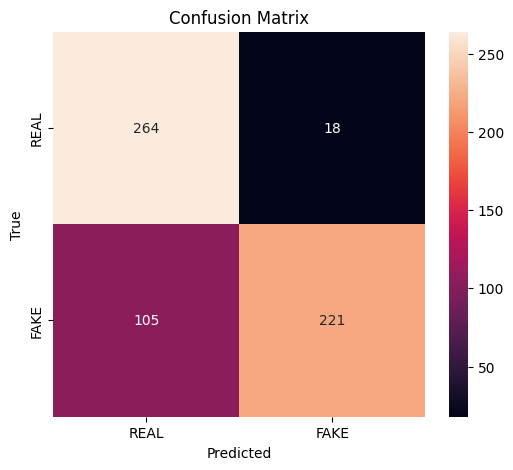

In [19]:
# === Block: Model Testing & Evaluation ===

import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Rebuild dataset & loader for “test” splits:
#    If you already have X_test & y_test lists from your split, skip this and just wrap them,
#    otherwise you can reuse the FaceFrameDataset class and point it at your saved faces.
test_ds = FaceFrameDataset(X_val, y_val, transform)   # or use X_test,y_test if you set aside a test split
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 2) Load the trained weights
model.load_state_dict(torch.load("resnext101_deepfake_faces.pth", map_location=device))
model.eval()

# 3) Collect predictions and true labels
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# 4) Compute metrics
acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["REAL","FAKE"]))

# 5) Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", 
            xticklabels=["REAL","FAKE"], 
            yticklabels=["REAL","FAKE"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [20]:
import torch

# 1) Ensure your model and utilities are loaded:
#    - model: your ResNeXt101 face‐crop classifier (already .to(device))
#    - extract_faces_from_video(), transform, device from earlier code

# Load trained weights
model.load_state_dict(torch.load("resnext101_deepfake_faces.pth", map_location=device))

# 2) Define the sample video path (replace with your file)
sample_path = "/kaggle/input/datasets/hungle3401/faceforensics/FF++/real/01__podium_speech_happy.mp4"
# 3) Run prediction
label, confidence, details = predict_video(
    sample_path,
    model,
    transform,
    device,
    frame_count=10,
    return_details=True
)

# 4) Print results
print("=== Video Deepfake Prediction ===")
print(f"Video File : {sample_path}")
print(f"Prediction : {label}")
print(f"Confidence : {confidence:.2f}")
print("\nPer-frame probabilities:")
for idx, (r_prob, f_prob) in enumerate(zip(details["real_probs"], details["fake_probs"])):
    print(f" Frame {idx+1:2d} → REAL: {r_prob:.2f}, FAKE: {f_prob:.2f}")


=== Video Deepfake Prediction ===
Video File : /kaggle/input/datasets/hungle3401/faceforensics/FF++/real/01__podium_speech_happy.mp4
Prediction : REAL
Confidence : 0.88

Per-frame probabilities:
 Frame  1 → REAL: 0.94, FAKE: 0.06
 Frame  2 → REAL: 0.84, FAKE: 0.16
 Frame  3 → REAL: 0.86, FAKE: 0.14
 Frame  4 → REAL: 0.71, FAKE: 0.29
 Frame  5 → REAL: 0.91, FAKE: 0.09
 Frame  6 → REAL: 0.91, FAKE: 0.09
 Frame  7 → REAL: 0.94, FAKE: 0.06
 Frame  8 → REAL: 0.95, FAKE: 0.05
 Frame  9 → REAL: 0.87, FAKE: 0.13
 Frame 10 → REAL: 0.89, FAKE: 0.11


In [21]:
import os

model_path = "/kaggle/working/resnext101_deepfake_faces.pth"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

Model exists: True
Model size: 335.88 MB
